# RT60 Parameter Sweep — Karplus-Strong

Plots the RT60 (computed analytically via `ksa_f0_pole_rt60`) as a function of loop filter coefficient `a1` and loop gain `g` for three fundamental frequencies: **80 Hz**, **320 Hz**, **1280 Hz**.

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm
from synths.dsp import ksa_f0_pole_rt60, FS_MIN   # <-- edit me

FS = FS_MIN

In [91]:
N = 200

a1_vals = np.logspace(-4, np.log10(0.999), N)

g_complement = np.logspace(-4, np.log10(0.999), N)   # = 1 - g, dense near 0
g_vals = 1.0 - g_complement                            # actual g, dense near 1

A1, G = np.meshgrid(a1_vals, g_vals)

F0s = [80, 320, 1280]

In [92]:
from synths.dsp import (
    one_pole_phase_delay,
    lagrange_fractional_delay,
    LAGRANGE_ORDER,
)
from tqdm.notebook import tqdm

def compute_rt60_grid(f0: float) -> np.ndarray:
    """Return an (N, N) array of RT60 values on the (g, a1) grid."""
    rt60_grid = np.zeros_like(A1)
    L_nominal = FS / f0
    with tqdm(total=N * N, desc=f"f0={f0} Hz", unit="cell") as pbar:
        for i in range(N):
            for j in range(N):
                a1 = A1[i, j]
                g  = G[i, j]
                pd = one_pole_phase_delay(f0, a1, FS)
                L_corrected = L_nominal + pd
                L_int, h = lagrange_fractional_delay(L_corrected, LAGRANGE_ORDER)
                rt60_grid[i, j] = ksa_f0_pole_rt60(
                    f0=f0, a1=a1, g=g, L_int=L_int, h=h, fs=FS
                )
                pbar.update(1)
    return rt60_grid

grids = {f0: compute_rt60_grid(f0) for f0 in F0s}
print("Done.")

f0=80 Hz:   0%|          | 0/40000 [00:00<?, ?cell/s]

f0=320 Hz:   0%|          | 0/40000 [00:00<?, ?cell/s]

f0=1280 Hz:   0%|          | 0/40000 [00:00<?, ?cell/s]

Done.


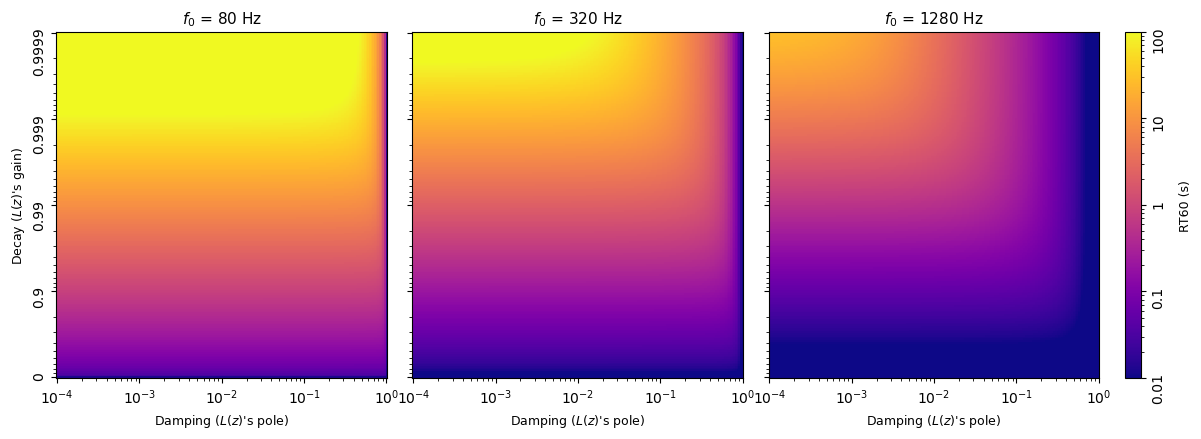

In [93]:
# -----------------------------------------------------------------
# Plot — one row, log colour scale only
# -----------------------------------------------------------------
CLIP_MAX = 100.0
HSPACE    = 0.1   # horizontal space between plots
CBAR_WIDTH = 0.05  # fraction of figure width for the colorbar column

fig = plt.figure(figsize=(14, 4.5))
gs = fig.add_gridspec(
    1, 4,
    width_ratios=[1, 1, 1, CBAR_WIDTH],
    wspace=HSPACE,
)

axes = [fig.add_subplot(gs[0, 0])]
for i in range(1, 3):
    axes.append(fig.add_subplot(gs[0, i], sharey=axes[0]))
cbar_ax = fig.add_subplot(gs[0, 3])

cb_ticks = [0.01, 0.1, 1.0, 10.0, 100.0]

for col, (ax, f0) in enumerate(zip(axes, F0s)):
    data = np.clip(grids[f0], 1e-4, CLIP_MAX)

    im = ax.pcolormesh(
        a1_vals, g_complement, data,
        cmap="plasma",
        norm=LogNorm(vmin=1e-2, vmax=CLIP_MAX),
        shading="auto",
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.invert_yaxis()

    # a1 x-axis: scientific notation as 10^n
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(
        lambda x, _: f"$10^{{{int(round(np.log10(x)))}}}$" if x > 0 else ""
    ))

    # g y-axis: show actual g = 1 - complement, rotated to match title direction
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{1 - x:.4g}"))
    ax.tick_params(axis="y", labelrotation=90)

    ax.set_title(f"$f_0$ = {f0} Hz", fontsize=11)
    ax.set_xlabel("Damping ($L(z)$'s pole)", fontsize=9)

    if col == 0:
        ax.set_ylabel("Decay ($L(z)$'s gain)", fontsize=9)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

cb = fig.colorbar(im, cax=cbar_ax, ticks=cb_ticks)
cb.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:g}"))
cb.ax.tick_params(labelrotation=90)
cb.set_label("RT60 (s)", fontsize=9, rotation=90, labelpad=10)

plt.show()